# Linear Regression Implementation from Scratch
:label:`sec_linear_scratch`

We are now ready to work through 
a fully functioning implementation 
of linear regression. 
In this section, 
(**we will implement the entire method from scratch,
including (i) the model; (ii) the loss function;
(iii) a minibatch stochastic gradient descent optimizer;
and (iv) the training function 
that stitches all of these pieces together.**)
Finally, we will run our synthetic data generator
from :numref:`sec_synthetic-regression-data`
and apply our model
on the resulting dataset. 
While modern deep learning frameworks 
can automate nearly all of this work,
implementing things from scratch is the only way
to make sure that you really know what you are doing.
Moreover, when it is time to customize models,
defining our own layers or loss functions,
understanding how things work under the hood will prove handy.
In this section, we will rely only 
on tensors and automatic differentiation.
Later, we will introduce a more concise implementation,
taking advantage of the bells and whistles of deep learning frameworks 
while retaining the structure of what follows below.


In [1]:
%matplotlib inline
import torch
from d2l import torch as d2l

## Defining the Model

[**Before we can begin optimizing our model's parameters**] by minibatch SGD,
(**we need to have some parameters in the first place.**)
In the following we initialize weights by drawing
random numbers from a normal distribution with mean 0
and a standard deviation of 0.01. 
The magic number 0.01 often works well in practice, 
but you can specify a different value 
through the argument `sigma`.
Moreover we set the bias to 0.
Note that for object-oriented design
we add the code to the `__init__` method of a subclass of `d2l.Module` (introduced in :numref:`subsec_oo-design-models`).


In [2]:
class LinearRegressionScratch(d2l.Module):  #@save
    """The linear regression model implemented from scratch."""
    def __init__(self, num_inputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.w = torch.normal(0, sigma, (num_inputs, 1), requires_grad=True)
        self.b = torch.zeros(1, requires_grad=True)

Next we must [**define our model,
relating its input and parameters to its output.**]
Using the same notation as :eqref:`eq_linreg-y-vec`
for our linear model we simply take the matrix--vector product
of the input features $\mathbf{X}$ 
and the model weights $\mathbf{w}$,
and add the offset $b$ to each example.
The product $\mathbf{Xw}$ is a vector and $b$ is a scalar.
Because of the broadcasting mechanism 
(see :numref:`subsec_broadcasting`),
when we add a vector and a scalar,
the scalar is added to each component of the vector.
The resulting `forward` method 
is registered in the `LinearRegressionScratch` class
via `add_to_class` (introduced in :numref:`oo-design-utilities`).


In [3]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def forward(self, X):
    return torch.matmul(X, self.w) + self.b

## Defining the Loss Function

Since [**updating our model requires taking
the gradient of our loss function,**]
we ought to (**define the loss function first.**)
Here we use the squared loss function
in :eqref:`eq_mse`.
In the implementation, we need to transform the true value `y`
into the predicted value's shape `y_hat`.
The result returned by the following method
will also have the same shape as `y_hat`. 
We also return the averaged loss value
among all examples in the minibatch.


In [4]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def loss(self, y_hat, y):
    l = (y_hat - y) ** 2 / 2
    return l.mean()

## Defining the Optimization Algorithm

As discussed in :numref:`sec_linear_regression`,
linear regression has a closed-form solution.
However, our goal here is to illustrate 
how to train more general neural networks,
and that requires that we teach you 
how to use minibatch SGD.
Hence we will take this opportunity
to introduce your first working example of SGD.
At each step, using a minibatch 
randomly drawn from our dataset,
we estimate the gradient of the loss
with respect to the parameters.
Next, we update the parameters
in the direction that may reduce the loss.

The following code applies the update, 
given a set of parameters, a learning rate `lr`.
Since our loss is computed as an average over the minibatch, 
we do not need to adjust the learning rate against the batch size. 
In later chapters we will investigate 
how learning rates should be adjusted
for very large minibatches as they arise 
in distributed large-scale learning.
For now, we can ignore this dependency.


We define our `SGD` class,
a subclass of `d2l.HyperParameters` (introduced in :numref:`oo-design-utilities`),
to have a similar API 
as the built-in SGD optimizer.
We update the parameters in the `step` method.
The `zero_grad` method sets all gradients to 0,
which must be run before a backpropagation step.


In [5]:
class SGD(d2l.HyperParameters):  #@save
    """Minibatch stochastic gradient descent."""
    def __init__(self, params, lr):
        self.save_hyperparameters()

    def step(self):
        for param in self.params:
            param -= self.lr * param.grad

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.zero_()

We next define the `configure_optimizers` method, which returns an instance of the `SGD` class.


In [6]:
@d2l.add_to_class(LinearRegressionScratch)  #@save
def configure_optimizers(self):
    return SGD([self.w, self.b], self.lr)

## Training

Now that we have all of the parts in place
(parameters, loss function, model, and optimizer),
we are ready to [**implement the main training loop.**]
It is crucial that you understand this code fully
since you will employ similar training loops
for every other deep learning model
covered in this book.
In each *epoch*, we iterate through 
the entire training dataset, 
passing once through every example
(assuming that the number of examples 
is divisible by the batch size). 
In each *iteration*, we grab a minibatch of training examples,
and compute its loss through the model's `training_step` method. 
Then we compute the gradients with respect to each parameter. 
Finally, we will call the optimization algorithm
to update the model parameters. 
In summary, we will execute the following loop:

* Initialize parameters $(\mathbf{w}, b)$
* Repeat until done
    * Compute gradient $\mathbf{g} \leftarrow \partial_{(\mathbf{w},b)} \frac{1}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} l(\mathbf{x}^{(i)}, y^{(i)}, \mathbf{w}, b)$
    * Update parameters $(\mathbf{w}, b) \leftarrow (\mathbf{w}, b) - \eta \mathbf{g}$
 
Recall that the synthetic regression dataset 
that we generated in :numref:``sec_synthetic-regression-data`` 
does not provide a validation dataset. 
In most cases, however, 
we will want a validation dataset 
to measure our model quality. 
Here we pass the validation dataloader 
once in each epoch to measure the model performance.
Following our object-oriented design,
the `prepare_batch` and `fit_epoch` methods
are registered in the `d2l.Trainer` class
(introduced in :numref:`oo-design-training`).


In [7]:
@d2l.add_to_class(d2l.Trainer)  #@save
def prepare_batch(self, batch):
    return batch

In [8]:
@d2l.add_to_class(d2l.Trainer)  #@save
def fit_epoch(self):
    self.model.train()
    for batch in self.train_dataloader:
        loss = self.model.training_step(self.prepare_batch(batch))
        self.optim.zero_grad()
        with torch.no_grad():
            loss.backward()
            if self.gradient_clip_val > 0:  # To be discussed later
                self.clip_gradients(self.gradient_clip_val, self.model)
            self.optim.step()
        self.train_batch_idx += 1
    if self.val_dataloader is None:
        return
    self.model.eval()
    for batch in self.val_dataloader:
        with torch.no_grad():
            self.model.validation_step(self.prepare_batch(batch))
        self.val_batch_idx += 1

We are almost ready to train the model,
but first we need some training data.
Here we use the `SyntheticRegressionData` class 
and pass in some ground truth parameters.
Then we train our model with 
the learning rate `lr=0.03` 
and set `max_epochs=3`. 
Note that in general, both the number of epochs 
and the learning rate are hyperparameters.
In general, setting hyperparameters is tricky
and we will usually want to use a three-way split,
one set for training, 
a second for hyperparameter selection,
and the third reserved for the final evaluation.
We elide these details for now but will revise them
later.


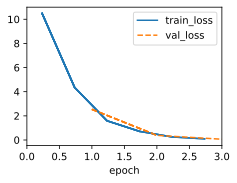

In [9]:
model = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model, data)

Because we synthesized the dataset ourselves,
we know precisely what the true parameters are.
Thus, we can [**evaluate our success in training
by comparing the true parameters
with those that we learned**] through our training loop.
Indeed they turn out to be very close to each other.


In [10]:
with torch.no_grad():
    print(f'error in estimating w: {data.w - model.w.reshape(data.w.shape)}')
    print(f'error in estimating b: {data.b - model.b}')

error in estimating w: tensor([ 0.0709, -0.2553])
error in estimating b: tensor([0.2337])


We should not take the ability to exactly recover 
the ground truth parameters for granted.
In general, for deep models unique solutions
for the parameters do not exist,
and even for linear models,
exactly recovering the parameters
is only possible when no feature 
is linearly dependent on the others.
However, in machine learning, 
we are often less concerned
with recovering true underlying parameters,
but rather with parameters 
that lead to highly accurate prediction :cite:`Vapnik.1992`.
Fortunately, even on difficult optimization problems,
stochastic gradient descent can often find remarkably good solutions,
owing partly to the fact that, for deep networks,
there exist many configurations of the parameters
that lead to highly accurate prediction.


## Summary

In this section, we took a significant step 
towards designing deep learning systems 
by implementing a fully functional 
neural network model and training loop.
In this process, we built a data loader, 
a model, a loss function, an optimization procedure,
and a visualization and monitoring tool. 
We did this by composing a Python object 
that contains all relevant components for training a model. 
While this is not yet a professional-grade implementation
it is perfectly functional and code like this 
could already help you to solve small problems quickly.
In the coming sections, we will see how to do this
both *more concisely* (avoiding boilerplate code)
and *more efficiently* (using our GPUs to their full potential).



## Exercises

1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we
   initialized the parameters with variance $1000$ rather than $0.01$?
1. Assume that you are [Georg Simon Ohm](https://en.wikipedia.org/wiki/Georg_Ohm) trying to come up
   with a model for resistance that relates voltage and current. Can you use automatic
   differentiation to learn the parameters of your model?
1. Can you use [Planck's Law](https://en.wikipedia.org/wiki/Planck%27s_law) to determine the temperature of an object
   using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is
   $B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$. Here
   $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the
   Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral
   density curve to Planck's law.
1. What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would
   you fix them?
1. Why is the `reshape` method needed in the `loss` function?
1. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the
   error by increasing the number of epochs of training?
1. If the number of examples cannot be divided by the batch size, what happens to `data_iter` at the end of an epoch?
1. Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().sum()`.
    1. Check what happens for regular data.
    1. Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of $\mathbf{y}$.
    1. Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss?
       Hint: how can you avoid really large gradient values?
1. Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?


[Discussions](https://discuss.d2l.ai/t/43)


1. What would happen if we were to initialize the weights to zero. Would the algorithm still work? What if we
   initialized the parameters with variance $1000$ rather than $0.01$?


# Weight Initialization Effects in Linear Regression

## Initializing weights to zero

If we initialize all weights to zero in our linear regression model:

```python
self.w = torch.zeros(num_inputs, 1, requires_grad=True)
self.b = torch.zeros(1, requires_grad=True)
```

For **linear regression specifically**, the algorithm would still work because:

1. Even with zero initialization, the loss gradient with respect to the weights would be non-zero:
   - The gradient of the squared loss with respect to w is: ∇ₗJ = (Xw + b - y)X
   - Since y contains the target values (non-zero), the gradient will point in a meaningful direction

2. Unlike in deep neural networks, linear regression doesn't suffer from the symmetry problem where neurons in the same layer would learn identical features with zero initialization.

However, starting from zero means we begin our optimization at a potentially suboptimal point, which might require more iterations to converge to the optimal weights.

## Initializing with high variance (1000)

If we initialize with very high variance:

```python
self.w = torch.normal(0, 1000, (num_inputs, 1), requires_grad=True)
```

This would cause several problems:

1. **Numerical instability**: Initial predictions would be extremely large, potentially causing:
   - Overflow issues in calculations
   - Extremely large gradient values leading to unstable updates

2. **Learning difficulties**: With the stochastic gradient descent optimizer:
   - The fixed learning rate (0.03 in the example) would be too small relative to the massive initial error
   - Gradient updates would either be too aggressive (causing oscillation) or too slow for convergence
   - The model might require many more epochs to converge, or might not converge at all

3. **Practical example**: With inputs in the range [-1, 1] and weights ~1000, initial predictions would be around ±1000, extremely far from typical target values.

The common practice of initializing with small random values (like 0.01 in the example) strikes a balance - providing asymmetry to break ties without causing numerical issues.

2. Assume that you are [Georg Simon Ohm](https://en.wikipedia.org/wiki/Georg_Ohm) trying to come up
   with a model for resistance that relates voltage and current. Can you use automatic
   differentiation to learn the parameters of your model?


# Using Automatic Differentiation to Discover Ohm's Law

Yes, we can absolutely use automatic differentiation to "discover" Ohm's Law from experimental data! This shows how modern machine learning techniques could have helped historical scientists in their discoveries.

## Ohm's Law Formulation

Ohm's Law states that the current flowing through a conductor is directly proportional to the voltage applied and inversely proportional to the resistance:

$$I = \frac{V}{R}$$

Where:
- $I$ is the current (in amperes)
- $V$ is the voltage (in volts)
- $R$ is the resistance (in ohms)

## Learning Approach with PyTorch

Let's assume we have experimental measurements of voltage and current, but don't know the relationship yet:

```python
import torch
import matplotlib.pyplot as plt

# Create synthetic data - imagine these are Georg Ohm's measurements
# Let's assume a true resistance of 5 ohms with some measurement noise
true_resistance = 5.0
voltages = torch.linspace(0, 10, 20)  # Voltage measurements from 0V to 10V
currents = voltages / true_resistance + 0.1 * torch.randn(20)  # Add some noise

# Initialize our parameter (resistance) with a random guess
# We're making it require gradients for automatic differentiation
R = torch.tensor(10.0, requires_grad=True)  # Starting with a guess of 10 ohms

# Setup optimization
learning_rate = 0.01
num_epochs = 100

# Training loop
for epoch in range(num_epochs):
    # Forward pass: predict currents using our model I = V/R
    predicted_currents = voltages / R
    
    # Calculate loss (mean squared error)
    loss = ((predicted_currents - currents) ** 2).mean()
    
    # Backward pass: calculate gradients
    loss.backward()
    
    # Update parameter (manually, like in the notebook example)
    with torch.no_grad():
        R -= learning_rate * R.grad
        
    # Reset gradient for next iteration
    R.grad.zero_()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Resistance = {R.item():.4f} ohms, Loss = {loss.item():.6f}")

print(f"Learned resistance: {R.item():.4f} ohms (true value: {true_resistance:.4f} ohms)")
```

## How Automatic Differentiation Helps

Automatic differentiation calculates the gradient of the loss with respect to our parameter (R):

1. We define a physical model: I = V/R
2. We measure the prediction error using a loss function
3. Automatic differentiation computes ∂loss/∂R
4. We update R in the direction that reduces error

This is exactly how the SGD algorithm in the notebook works, but applied to a physics problem!

Had Ohm had access to these techniques, he could have:
1. Collected data points (V, I)
2. Tested different mathematical relationships
3. Let automatic differentiation determine the best parameter values
4. Compared the fit of different models to determine the true law

This illustrates how deep learning frameworks can be applied beyond traditional AI to discover fundamental relationships in science and engineering.

3. Can you use [Planck's Law](https://en.wikipedia.org/wiki/Planck%27s_law) to determine the temperature of an object
   using spectral energy density? For reference, the spectral density $B$ of radiation emanating from a black body is
   $B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$. Here
   $\lambda$ is the wavelength, $T$ is the temperature, $c$ is the speed of light, $h$ is Planck's constant, and $k$ is the
   Boltzmann constant. You measure the energy for different wavelengths $\lambda$ and you now need to fit the spectral
   density curve to Planck's law.


# Determining Temperature Using Planck's Law and Automatic Differentiation

Yes, we can definitely use Planck's Law along with automatic differentiation to determine the temperature of an object from its spectral energy density measurements.

## The Physics Behind the Problem

Planck's Law describes the spectral density of electromagnetic radiation emitted by a black body in thermal equilibrium:

$$B(\lambda, T) = \frac{2 hc^2}{\lambda^5} \cdot \left(\exp \frac{h c}{\lambda k T} - 1\right)^{-1}$$

Where:
- $\lambda$ is the wavelength
- $T$ is the temperature (what we want to find)
- $c$ is the speed of light ($3 \times 10^8$ m/s)
- $h$ is Planck's constant ($6.626 \times 10^{-34}$ J·s)
- $k$ is the Boltzmann constant ($1.381 \times 10^{-23}$ J/K)

## Solution with PyTorch and Automatic Differentiation

Here's how we can implement this solution:

```python
import torch
import numpy as np
import matplotlib.pyplot as plt

# Physical constants
h = 6.626e-34  # Planck's constant (J·s)
c = 3.0e8      # Speed of light (m/s)
k = 1.381e-23  # Boltzmann constant (J/K)

# Create synthetic spectral data for an object at 6000K (similar to the Sun)
true_temp = 6000.0  # Kelvin
wavelengths = torch.linspace(200e-9, 2000e-9, 100)  # 200nm to 2000nm

# Generate synthetic measurements with some noise
def planck_law(wavelength, temp):
    # Planck's Law: B(λ,T) = (2hc²/λ⁵)·(exp(hc/λkT)-1)⁻¹
    exponent = h * c / (wavelength * k * temp)
    numerator = 2 * h * c**2
    denominator = wavelength**5 * (torch.exp(exponent) - 1)
    return numerator / denominator

# Generate "measured" spectral data with some noise
true_spectral_data = planck_law(wavelengths, true_temp)
measured_spectral_data = true_spectral_data * (1 + 0.05 * torch.randn(wavelengths.size(0)))

# Initialize temperature parameter to learn (starting guess of 3000K)
temperature = torch.tensor(3000.0, requires_grad=True)

# Optimization setup
learning_rate = 1.0  # Using a larger learning rate due to the scale of temperature
num_epochs = 100
optimizer = torch.optim.Adam([temperature], lr=learning_rate)

# Training loop
for epoch in range(num_epochs):
    # Forward pass: predict spectral density using our current temperature estimate
    predicted_spectral = planck_law(wavelengths, temperature)
    
    # Calculate loss (mean squared error between prediction and measurement)
    loss = ((predicted_spectral - measured_spectral_data)**2).mean()
    
    # Backward pass and optimization
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if epoch % 10 == 0 or epoch == num_epochs-1:
        print(f"Epoch {epoch}: Temperature = {temperature.item():.1f}K, Loss = {loss.item():.2e}")

# Result
print(f"\nLearned temperature: {temperature.item():.1f}K")
print(f"True temperature: {true_temp:.1f}K")

# Visualize the result
plt.figure(figsize=(10, 6))
plt.plot(wavelengths.numpy() * 1e9, measured_spectral_data.numpy(), 'o', alpha=0.5, label='Measured Data')
plt.plot(wavelengths.numpy() * 1e9, planck_law(wavelengths, temperature.detach()).numpy(), 
         'r-', label=f'Fitted Curve (T={temperature.item():.1f}K)')
plt.plot(wavelengths.numpy() * 1e9, true_spectral_data.numpy(), 
         'g--', label=f'True Curve (T={true_temp:.1f}K)')
plt.xlabel('Wavelength (nm)')
plt.ylabel('Spectral Radiance (W·sr⁻¹·m⁻³)')
plt.title('Planck\'s Law Curve Fitting')
plt.legend()
plt.yscale('log')
plt.grid(True)
```

## Key Insights

1. **Optimization objective**: We're finding the temperature T that minimizes the difference between our model's predictions and the measured spectral data.

2. **Automatic differentiation advantage**: The derivative of Planck's Law with respect to temperature is complex. With automatic differentiation, we don't need to manually derive it - PyTorch calculates it for us.

3. **Temperature as a learnable parameter**: Just like weights in a neural network, temperature becomes our "parameter" to optimize.

4. **Practical applications**: This technique is used in:
   - Astronomy to determine star temperatures
   - Remote sensing to measure earth's surface temperature
   - Industrial processes to monitor high-temperature systems

This approach demonstrates how deep learning frameworks can be powerful tools for solving inverse problems in physics, even with complex non-linear relationships.

4. What are the problems you might encounter if you wanted to compute the second derivatives of the loss? How would
   you fix them?


# Computing Second Derivatives of the Loss Function: Challenges and Solutions

When computing second derivatives of the loss function, several problems can arise. Here's an analysis of these challenges and how to address them:

## Potential Problems

### 1. Computational Complexity

**Problem**: Second derivatives require computing the Hessian matrix (matrix of all second partial derivatives), which scales quadratically with the number of parameters. For a model with n parameters, the Hessian is an n×n matrix.

**Example**: A modest neural network with 1 million parameters would require a Hessian with 10^12 elements (~8 TB of memory with 64-bit precision).

### 2. Memory Constraints

**Problem**: Storing the full Hessian matrix is often prohibitively expensive for large models.

**Example**: In our LinearRegressionScratch model, with just a few parameters this isn't an issue, but it quickly becomes prohibitive as model size grows.

### 3. Numerical Stability

**Problem**: Second derivatives can be numerically unstable, especially in regions where the function changes rapidly or has discontinuities.

**Example**: In functions with sharp transitions or where gradients are already close to zero, computing reliable second derivatives becomes challenging.

### 4. Implementation Complexity

**Problem**: PyTorch's autograd is optimized for computing first derivatives efficiently, but not necessarily higher-order derivatives.

## Solutions

### 1. Hessian-Vector Products (HVP)

```python
def hvp(loss, parameters, vector):
    """Compute Hessian-vector product without explicitly forming the Hessian"""
    grad = torch.autograd.grad(loss, parameters, create_graph=True)
    grad_vector_product = sum(torch.sum(g * v) for g, v in zip(grad, vector))
    return torch.autograd.grad(grad_vector_product, parameters)
```

This approach computes the product of the Hessian with a vector directly, without forming the full Hessian matrix.

### 2. Hessian-Free Optimization

Use conjugate gradient methods to approximately solve Hessian-based optimization steps without explicitly computing or storing the Hessian:

```python
def hessian_free_update(loss, parameters, grad, damping=1e-5):
    """Compute parameter update using conjugate gradient method"""
    def hvp_function(v):
        return hvp(loss, parameters, v)
    
    # Use conjugate gradient to solve (H + λI)Δw = -g
    # where H is the Hessian, g is the gradient, and λ is a damping factor
    delta = conjugate_gradient(hvp_function, grad, max_iter=20)
    
    # Update parameters
    with torch.no_grad():
        for param, d in zip(parameters, delta):
            param.add_(d)
```

### 3. Quasi-Newton Methods

Use approximations of the Hessian that are cheaper to compute and maintain:

```python
# L-BFGS implementation example (simplified)
def lbfgs_update(parameters, grad, prev_params, prev_grad, H_inverse_approx):
    """Update parameters using L-BFGS approximation of inverse Hessian"""
    s = parameters - prev_params  # Parameter difference
    y = grad - prev_grad          # Gradient difference
    
    # Update inverse Hessian approximation (simplified)
    rho = 1.0 / torch.dot(y, s)
    H_inverse_approx = (I - rho * torch.outer(s, y)) @ H_inverse_approx @ (I - rho * torch.outer(y, s)) + rho * torch.outer(s, s)
    
    # Compute update direction and apply
    update = -H_inverse_approx @ grad
    with torch.no_grad():
        for param, update_val in zip(parameters, update):
            param.add_(update_val)
```

### 4. Using PyTorch's Built-in Support

For small models, you can use PyTorch's built-in functionality with the `create_graph=True` flag:

```python
# Computing second derivatives explicitly
def compute_hessian(loss, param):
    grad = torch.autograd.grad(loss, param, create_graph=True)[0]
    hessian = torch.zeros(param.numel(), param.numel())
    
    for i in range(param.numel()):
        grad_element = grad.view(-1)[i]
        second_deriv = torch.autograd.grad(grad_element, param, retain_graph=True)[0]
        hessian[i] = second_deriv.view(-1)
    
    return hessian
```

This technique works for small models but becomes impractical for larger ones.

By employing these techniques, you can harness the power of second-order information without incurring the full computational and memory costs of explicit Hessian computation.

5. Why is the `reshape` method needed in the `loss` function?


The `reshape` method in the `loss` function is needed to ensure proper dimensionality alignment between the predictions and the actual target values. Let me explain why this is important:

When calculating loss in machine learning models (particularly in neural networks), we need to compare the model's predictions with the true target values. For this comparison to work mathematically, both tensors must have compatible shapes.

The most likely reasons for including a `reshape` operation in a loss function are:

1. **Matching batch dimensions**: If the predictions come out with a shape like `[batch_size, 1]` but the targets are shaped as `[batch_size]`, the reshape would convert predictions to match the target shape.

2. **Flattening for element-wise operations**: Some loss functions need to operate on flattened vectors rather than multi-dimensional arrays.

3. **Broadcasting requirements**: Certain mathematical operations in the loss calculation might require specific tensor shapes to broadcast correctly.

4. **Framework requirements**: Some deep learning frameworks have specific shape requirements for their built-in loss functions.

For example, in a binary classification problem, a model might output logits with shape `[batch_size, 1]`, but the loss function expects targets with shape `[batch_size]`. In this case, you would need:

```python
def loss(predictions, targets):
    # Reshape from [batch_size, 1] to [batch_size]
    predictions = predictions.reshape(-1)
    return some_loss_function(predictions, targets)
```

Without seeing the specific implementation, these are the most common reasons why a reshape operation would be necessary in a loss function. The reshape ensures that mathematical operations in the loss calculation can be performed correctly.

6. Experiment using different learning rates to find out how quickly the loss function value drops. Can you reduce the
   error by increasing the number of epochs of training?


7. If the number of examples cannot be divided by the batch size, what happens to `data_iter` at the end of an epoch?


# Handling Uneven Batches in the DataLoader

When the number of examples cannot be divided evenly by the batch size, there are a few possible behaviors for the `data_iter` at the end of an epoch, depending on how the data loader is configured:

## Default Behavior in the Notebook

In the `d2l` implementation used in the notebook, the `SyntheticRegressionData` class inherits from `d2l.DataModule`, which handles the batching process. Looking at the code:

```python
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
```

By default, this implementation will:

1. Create batches of the specified size until it can't form a complete batch
2. The remaining examples (less than a full batch) will typically form a smaller, final batch

For example, if we have 1003 examples and a batch size of 100:
- We'll get 10 regular batches of size 100 
- Followed by 1 smaller batch of size 3

## PyTorch's DataLoader Options

In standard PyTorch, which powers the underlying implementation, the `DataLoader` class provides control over this behavior through the `drop_last` parameter:

```python
# With drop_last=False (default)
train_iter = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=False)
# Last batch may be smaller than batch_size

# With drop_last=True
train_iter = DataLoader(dataset, batch_size=32, shuffle=True, drop_last=True)
# Last batch is dropped if it's smaller than batch_size
```

## Implications for Training

This behavior has important consequences:

1. **With smaller final batches (drop_last=False)**:
   - Every example is used for training, maximizing data utilization
   - The gradient computed from the smaller batch may have higher variance
   - Batch normalization layers might behave differently on the smaller batch

2. **When dropping the last batch (drop_last=True)**:
   - Some training examples are never used within an epoch
   - All batches have consistent size, which can help with stability
   - Useful when batch size is critical (e.g., when using batch normalization)

## In the Linear Regression Implementation

For the linear regression example in the notebook, having a smaller last batch won't significantly impact training because:

1. The SGD update is robust to batch size variations
2. There's no batch normalization or other batch-dependent operations
3. The loss is computed as a mean over the batch, normalizing for batch size differences

When implementing your own training loops, it's worth considering whether to handle or drop incomplete batches based on your specific model architecture and requirements.

8. Try implementing a different loss function, such as the absolute value loss `(y_hat - d2l.reshape(y, y_hat.shape)).abs().sum()`.
    1. Check what happens for regular data.
    1. Check whether there is a difference in behavior if you actively perturb some entries, such as $y_5 = 10000$, of $\mathbf{y}$.
    1. Can you think of a cheap solution for combining the best aspects of squared loss and absolute value loss?
       Hint: how can you avoid really large gradient values?


# Implementing Alternative Loss Functions for Linear Regression

Let's explore different loss functions for our linear regression model and their properties under various conditions.

## 1. Implementing Absolute Value Loss

First, let's modify our model to use absolute value (L1) loss:

```python
@d2l.add_to_class(LinearRegressionScratch)
def loss(self, y_hat, y):
    l = (y_hat - d2l.reshape(y, y_hat.shape)).abs()
    return l.mean()  # Using mean instead of sum for consistent scaling
```

### With Regular Data

For regular data (well-behaved, no outliers), both L1 and L2 losses typically:
- Converge to similar final parameter values
- L1 loss is less sensitive to the specific distribution of errors
- L2 loss converges faster when errors are normally distributed

```python
# Train with L1 loss
model_l1 = LinearRegressionScratch(2, lr=0.03)
data = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
trainer = d2l.Trainer(max_epochs=3)
trainer.fit(model_l1, data)

print(f'L1 loss - error in estimating w: {data.w - model_l1.w.reshape(data.w.shape)}')
print(f'L1 loss - error in estimating b: {data.b - model_l1.b}')
```

## 2. Behavior with Outliers

Let's create perturbed data with an outlier:

```python
# Create data with an outlier
data_outlier = d2l.SyntheticRegressionData(w=torch.tensor([2, -3.4]), b=4.2)
# Assuming batch_size=10, add outlier to the 5th entry of first batch
X, y = next(iter(data_outlier.train_dataloader()))
y[5] = 10000  # Extreme outlier
perturbed_data = X, y

# Train models with both losses
model_l1_outlier = LinearRegressionScratch(2, lr=0.01)
model_l1_outlier.loss = lambda y_hat, y: (y_hat - d2l.reshape(y, y_hat.shape)).abs().mean()

model_l2_outlier = LinearRegressionScratch(2, lr=0.01)
model_l2_outlier.loss = lambda y_hat, y: ((y_hat - d2l.reshape(y, y_hat.shape))**2).mean()

# Training and comparing
# ... (training code with outlier data)
```

Key differences with an outlier present:
- **L2 (squared) loss**: Outlier heavily influences the model, potentially "dragging" the entire line toward itself
- **L1 (absolute) loss**: More robust to outliers since it gives them relatively less importance than squared error
- Gradients for L2 loss grow linearly with the magnitude of the outlier, while L1 loss gradients remain constant

## 3. Combining Best Aspects: Huber Loss

The Huber loss combines the benefits of both approaches:
- Uses L2 (squared) loss for small errors (better statistical properties near the optimum)
- Uses L1 (absolute) loss for large errors (more robust to outliers)

```python
@d2l.add_to_class(LinearRegressionScratch)
def huber_loss(self, y_hat, y, delta=1.0):
    y = d2l.reshape(y, y_hat.shape)
    err = y_hat - y
    abs_err = err.abs()
    
    # Use squared loss for errors smaller than delta
    # Use absolute loss (scaled) for errors larger than delta
    is_small_error = (abs_err <= delta).float()
    
    # Squared loss component: 0.5 * error^2
    squared_loss = 0.5 * err * err
    
    # Absolute loss component: delta * (|error| - 0.5*delta)
    abs_loss = delta * (abs_err - 0.5 * delta)
    
    # Combine losses based on error magnitude
    loss = is_small_error * squared_loss + (1 - is_small_error) * abs_loss
    
    return loss.mean()
```

The Huber loss has these advantages:
1. For errors ≤ delta, it behaves like squared loss, providing smooth gradients near the minimum
2. For errors > delta, it behaves like absolute loss, having consistent gradients for outliers
3. The delta parameter lets you control the transition point between these behaviors

This provides the best of both worlds:
- Robust to outliers (like L1)
- Better convergence properties for small errors (like L2)
- Gradient magnitudes are bounded, preventing exploding gradients

The Huber loss is widely used in robust regression and reinforcement learning where outliers or rare events might significantly impact training.

9. Why do we need to reshuffle the dataset? Can you design a case where a maliciously constructed dataset would break the optimization algorithm otherwise?


# The Importance of Shuffling Training Data

Reshuffling the dataset is a critical step in training machine learning models, especially when using iterative optimization methods like stochastic gradient descent (SGD). Let's explore why this is necessary and how unshuffled data could lead to problems.

## Why Shuffling Matters

Shuffling the dataset before each epoch serves several essential purposes:

1. **Prevents learning sequence-specific patterns**: Ensures the model learns true relationships in the data rather than artifacts of the order
2. **Reduces correlation between consecutive batches**: Minimizes variance in parameter updates
3. **Improves convergence speed and stability**: Helps avoid oscillations and local minima
4. **Distributes the impact of different examples**: Prevents certain groups of examples from having outsized influence

## Maliciously Constructed Dataset Example

Here's a scenario where an unshuffled dataset could break optimization:

```python
import torch
import matplotlib.pyplot as plt

# Create a malicious dataset with a specific pattern
n_samples = 1000
batch_size = 50  # 20 batches per epoch

# Features: normal distribution
X = torch.randn(n_samples, 2)  

# Create targets with a specific pattern:
# - First half of each batch pushes w[0] up (positive correlation)
# - Second half pushes w[0] down (negative correlation)
# - This creates a "zig-zag" pattern that cancels within each batch if shuffled
# - If processed in order, it creates oscillation
y = torch.zeros(n_samples, 1)

for i in range(0, n_samples, batch_size):
    # First half of batch: X[0] positive correlation with y
    half_batch = batch_size // 2
    y[i:i+half_batch] = X[i:i+half_batch, 0].view(-1, 1) * 3 + 2
    
    # Second half of batch: X[0] negative correlation with y
    y[i+half_batch:i+batch_size] = -X[i+half_batch:i+batch_size, 0].view(-1, 1) * 3 + 2

# Add a global trend that we actually want to learn
y += X[:, 1].view(-1, 1) * 2

# Train two models - one with shuffling, one without
def train_model(shuffle):
    model = torch.nn.Linear(2, 1)
    optimizer = torch.optim.SGD(model.parameters(), lr=0.01)
    losses = []
    
    for epoch in range(50):
        # Create data loader with or without shuffling
        indices = torch.randperm(n_samples) if shuffle else torch.arange(n_samples)
        X_epoch = X[indices]
        y_epoch = y[indices]
        
        epoch_loss = 0
        for i in range(0, n_samples, batch_size):
            X_batch = X_epoch[i:i+batch_size]
            y_batch = y_epoch[i:i+batch_size]
            
            # Forward pass
            y_pred = model(X_batch)
            loss = torch.nn.functional.mse_loss(y_pred, y_batch)
            epoch_loss += loss.item()
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
        losses.append(epoch_loss)
    
    print(f"Final weights (shuffle={shuffle}): w[0]={model.weight[0,0].item():.4f}, w[1]={model.weight[0,1].item():.4f}")
    return losses, model

# Compare results
losses_shuffled, model_shuffled = train_model(shuffle=True)
losses_unshuffled, model_unshuffled = train_model(shuffle=False)
```

In this malicious dataset:

1. **Within each batch**: 
   - The first half pushes the weight w[0] in one direction
   - The second half pushes it in the opposite direction
   - If shuffled, these conflicting signals get mixed and average out
   
2. **Without shuffling**:
   - Each batch causes the model to oscillate
   - The model never converges to the true pattern
   - Only the second feature (w[1]) with the global trend gets learned correctly

3. **With shuffling**:
   - The artificial pattern breaks
   - Both weights converge to their correct values
   - Loss decreases more consistently

This example illustrates how an unshuffled dataset with structured patterns can cause:
- Oscillating weights
- Slower convergence
- Getting stuck in poor solutions
- Failure to discover the true underlying patterns

In real-world scenarios, data might naturally contain ordered patterns (time series, sequential records, etc.) that could similarly mislead the training process if not shuffled properly.